## EfficientNet + CBAM for Solar Cell Defect Detection

### Problem Setup
We perform **binary classification** on solar cell images:

- **Class 0 (`OK`)** → defect-free cells  
- **Class 1 (`Bgrade`)** → defective cells  

The objective is to **maximize defect detection (recall)** while maintaining strong overall performance.

---

## Why EfficientNet?

While ResNet provides strong baselines, **EfficientNet** offers:

- Better **parameter efficiency**
- Improved **feature scaling (depth, width, resolution)**
- Strong performance on **fine-grained visual patterns**

This makes it particularly effective for detecting:
- Micro-cracks
- Discoloration
- Subtle surface defects

---

## Why Add CBAM?

To further enhance defect localization, we integrate **CBAM (Convolutional Block Attention Module)**:

- **Channel Attention** → focuses on important feature maps  
- **Spatial Attention** → highlights defect regions  

This improves sensitivity to **small, low-contrast anomalies**.

---

## Model Architecture

Input Image (224×224)
↓
EfficientNet-B0 Feature Extractor
↓
CBAM (Channel + Spatial Attention)
↓
Global Average Pooling
↓
Fully Connected Layer (1 output)
↓
Sigmoid (for inference)

---

## Model Implementation

```python
import torch
import torch.nn as nn
from torchvision import models

# --- CBAM Modules ---
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.fc(self.avg_pool(x)) +
            self.fc(self.max_pool(x))
        )

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size,
                              padding=kernel_size // 2,
                              bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# --- EfficientNet + CBAM ---
class EfficientNet_CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b0(pretrained=True)

        # Last feature layer has 1280 channels
        self.cbam = CBAM(1280)

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.cbam(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.classifier(x)

        return x
````

---

## Training Strategy

* **Loss Function**: `BCEWithLogitsLoss` (with class imbalance weighting)
* **Optimizer**: Adam
* **Learning Rate**: `3e-5` (lower for EfficientNet)
* **Fine-tuning**:

  * Freeze early layers
  * Train deeper layers + CBAM

```python
for param in model.backbone.features[:4].parameters():
    param.requires_grad = False
```

---

## Data Augmentation

* Random Horizontal Flip
* Random Rotation (±5°)
* Color Jitter (low intensity)
* Random Resized Crop

---

## Evaluation Metrics

For defect detection, accuracy is insufficient.

We prioritize:

* **Recall (Bgrade)** → minimize missed defects
* **F1-score** → balance precision & recall
* **Confusion Matrix**

---

## Expected Benefits

* Better detection of **subtle defects**
* Improved **recall for defective cells**
* Stronger **generalization** vs ResNet
* Attention-guided focus on **critical regions**

---

## Future Improvements

* Grad-CAM visualization for explainability
* EfficientNet-B3/B4 for higher accuracy
* Ensemble with ResNet + ViT
* Deployment using ONNX / TensorRT


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score

In [2]:
from torchvision.datasets import ImageFolder

class SafeImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)

        valid_samples = []

        for path, label in self.samples:
            try:
                img = Image.open(path)
                img.verify()  # check corruption
                valid_samples.append((path, label))
            except Exception:
                print(f"⚠️ Skipping corrupted image: {path}")

        self.samples = valid_samples

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [4]:
DATA_PATH = r"C:\Users\my\PVModulecv\ResNetTrainData"

full_dataset = SafeImageFolder(DATA_PATH)

train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

torch.manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = val_transform
test_dataset.dataset.transform  = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [5]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes//ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes//ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.fc(self.avg_pool(x)) +
            self.fc(self.max_pool(x))
        )

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3,bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx,_ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg,mx], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

In [6]:
class EfficientNet_CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b0(pretrained=True)

        self.cbam = CBAM(1280)

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.cbam(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.classifier(x)
        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet_CBAM().to(device)

optimizer = optim.AdamW(model.parameters(), lr=3e-5)

labels = [label for _, label in full_dataset.samples]
class_counts = np.bincount(labels)

pos_weight = torch.tensor(class_counts[0] / class_counts[1]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

C:\Users\my\.conda\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\my\.conda\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\my/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


In [8]:
train_losses = []
val_accuracies = []
val_f1_scores = []
val_recalls = []

def validate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).int().squeeze(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)

    return acc, f1, recall, all_preds, all_labels


EPOCHS = 12

best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    acc, f1, recall, preds, labs = validate(model, val_loader)

    train_losses.append(train_loss)
    val_accuracies.append(acc)
    val_f1_scores.append(f1)
    val_recalls.append(recall)

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Recall={recall:.4f}")

    # ✅ SAVE BEST MODEL (based on F1 or Recall)
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_efficientnet_cbam.pth")
        print("✅ Best model saved!")

Epoch 1: Loss=0.3674, Acc=0.7991, F1=0.8363, Recall=0.7671
✅ Best model saved!
Epoch 2: Loss=0.2406, Acc=0.8720, F1=0.9020, Recall=0.8801
✅ Best model saved!
Epoch 3: Loss=0.1853, Acc=0.9098, F1=0.9335, Recall=0.9465
✅ Best model saved!
Epoch 4: Loss=0.1510, Acc=0.9237, F1=0.9433, Recall=0.9485
✅ Best model saved!
Epoch 5: Loss=0.1295, Acc=0.9244, F1=0.9447, Recall=0.9653
✅ Best model saved!
Epoch 6: Loss=0.1104, Acc=0.9251, F1=0.9451, Recall=0.9633
✅ Best model saved!
Epoch 7: Loss=0.0919, Acc=0.9284, F1=0.9473, Recall=0.9623
✅ Best model saved!
Epoch 8: Loss=0.0831, Acc=0.9264, F1=0.9460, Recall=0.9633
Epoch 9: Loss=0.0711, Acc=0.9284, F1=0.9472, Recall=0.9604
Epoch 10: Loss=0.0590, Acc=0.9290, F1=0.9477, Recall=0.9613
✅ Best model saved!
Epoch 11: Loss=0.0523, Acc=0.9271, F1=0.9461, Recall=0.9564
Epoch 12: Loss=0.0488, Acc=0.9264, F1=0.9457, Recall=0.9574


In [9]:
torch.save(model.state_dict(), "final_efficientnet_cbam.pth")
torch.save(model, "efficientnet_cbam_full.pth")

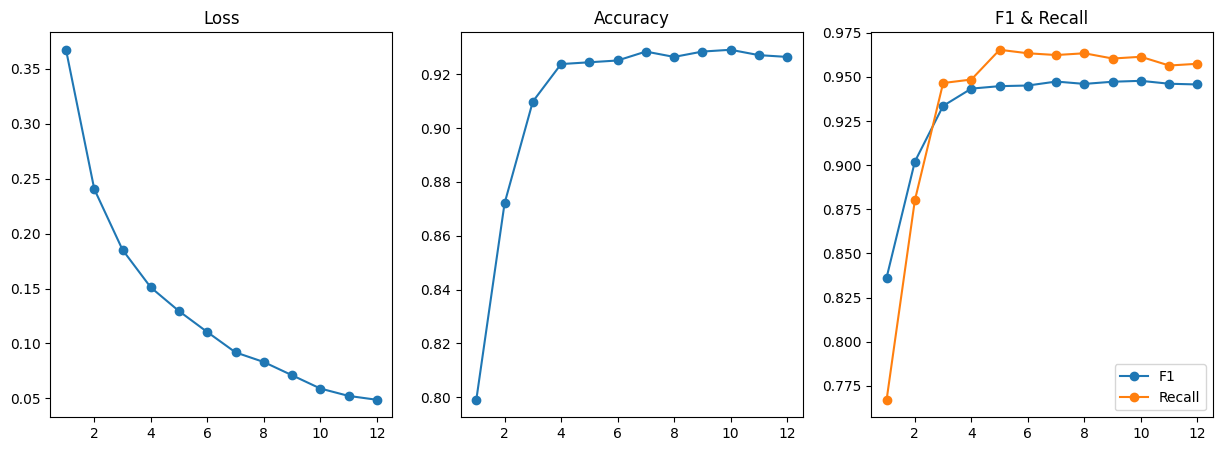

In [10]:
epochs = range(1, EPOCHS+1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(epochs, train_losses, 'o-')
plt.title("Loss")

plt.subplot(1,3,2)
plt.plot(epochs, val_accuracies, 'o-')
plt.title("Accuracy")

plt.subplot(1,3,3)
plt.plot(epochs, val_f1_scores, 'o-', label="F1")
plt.plot(epochs, val_recalls, 'o-', label="Recall")
plt.legend()
plt.title("F1 & Recall")

plt.show()

In [11]:
cm = confusion_matrix(labs, preds)
print(cm)

print(classification_report(labs, preds, target_names=["OK", "Bgrade"]))

[[431  68]
 [ 43 966]]
              precision    recall  f1-score   support

          OK       0.91      0.86      0.89       499
      Bgrade       0.93      0.96      0.95      1009

    accuracy                           0.93      1508
   macro avg       0.92      0.91      0.92      1508
weighted avg       0.93      0.93      0.93      1508



In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, x):
        self.model.zero_grad()

        output = self.model(x)
        output.backward()

        weights = torch.mean(self.gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam